# Homework 2: Social Network Influence Analysis

**Joao De Oliveira**

**Topics:** Eigenvalues and Eigenvectors

A marketing company wants to find the key influencers in a six-user social network before launching a product campaign. The network is stored as an adjacency matrix $A$, where $A_{ij} = 1$ if User $i$ and User $j$ are connected and $A_{ij} = 0$ if they aren't connected. I use the eigenvector of the dominant eigenvalue, which satisfies

$$A\mathbf{v} = \lambda\mathbf{v},$$

as a vector of relative influence scores.

**Workflow:** import and validate the data -> visualize the network -> compute and verify the dominant eigenpair -> rank users -> compare with degree -> business recommendation.

In [28]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import networkx as nx

np.set_printoptions(precision=4, suppress=True)
pd.set_option("display.precision", 4)

## Part A: Network Representation

### A.1 Import the dataset
The data is read directly from the raw file in my Github repository, so the notebook is reproducible on any machine with an internet connection. The `user` column holds labels, not network values, so it is used as the row index rather than as part of the numeric matrix. In case there is something wrong with downloading the file, the notebook falls back to a local copy of `network.csv` in the same folder.

In [29]:
DATA_URL = ("https://raw.githubusercontent.com/JDO-MSDS/DATA-605/"
            "refs/heads/main/Assignment2/network.csv")
LOCAL_COPY = "network.csv"

# user column is the index
try:
    df = pd.read_csv(DATA_URL, index_col="User")
    print(f"Loaded from GitHub: {DATA_URL}")
except Exception as e:
    print(f"Download failed ({type(e).__name__}); reading local copy instead.")
    df = pd.read_csv(LOCAL_COPY, index_col="User")

df

Loaded from GitHub: https://raw.githubusercontent.com/JDO-MSDS/DATA-605/refs/heads/main/Assignment2/network.csv


,User1,User2,User3,User4,User5,User6
User,,,,,,
User1,0,1,1,0,0,0
User2,1,0,1,1,0,1
User3,1,1,0,1,1,0
User4,0,1,1,0,1,0
User5,0,0,1,1,0,1
User6,0,1,0,0,1,0


### A.2 Build and validate the adjacency matrix
.

In [30]:
users = df.index.tolist()
A = df.to_numpy(dtype=float)

checks = {
    "Shape": A.shape,
    "Square matrix": A.shape[0] == A.shape[1],
    "Row labels == column labels": users == df.columns.tolist(),
    "Entries are only 0 or 1": bool(np.isin(A, [0, 1]).all()),
    "Diagonal is all zeros": bool(np.all(np.diag(A) == 0)),
    "Symmetric (A == A^T)": bool(np.allclose(A, A.T)),
}
for name, result in checks.items():
    print(f"{name:<30} {result}")

print("\nDiagonal:", np.diag(A))
print("Number of edges (undirected):", int(A.sum() / 2))

Shape                          (6, 6)
Square matrix                  True
Row labels == column labels    True
Entries are only 0 or 1        True
Diagonal is all zeros          True
Symmetric (A == A^T)           True

Diagonal: [0. 0. 0. 0. 0. 0.]
Number of edges (undirected): 9


$A$ is a $6 \times 6$ symmetric binary matrix with a zero diagonal, describing an undirected network with 9 connections, as expected.

### A.3 Direct connections (degree)
The degree of each user is the row sum of $A$. This is the "count the connections" measure I will use to compare against eigenvector centrality.

In [31]:
degree = pd.Series(A.sum(axis=1).astype(int), index=users, name="Degree")
neighbors = {u: [users[j] for j in np.flatnonzero(A[i])] for i, u in enumerate(users)}

degree_table = pd.DataFrame({
    "Degree": degree,
    "Connected to": [", ".join(neighbors[u]) for u in users],
})
degree_table

,Degree,Connected to
User1,2,"User2, User3"
User2,4,"User1, User3, User4, User6"
User3,4,"User1, User2, User4, User5"
User4,3,"User2, User3, User5"
User5,3,"User3, User4, User6"
User6,2,"User2, User5"


User2 and User3 are tied for the most direct connections (4 each), User4 and User5 have 3, and User1 and User6 have 2.

### A.4 Network visualization
Node size is proportional to degree so the direct structure is visible at a glance. A fixed random seed keeps the layout reproducible.

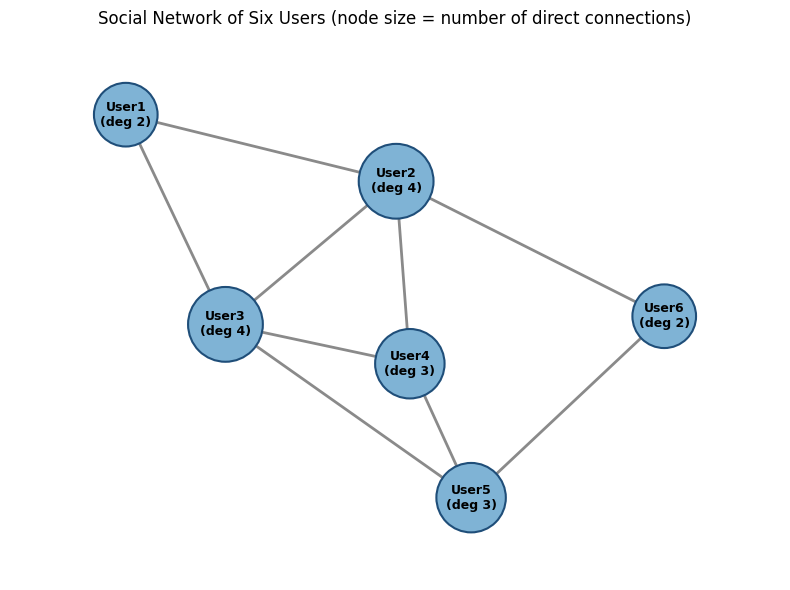

Nodes shown: 6 | Edges shown: 9


In [32]:
G = nx.from_pandas_adjacency(df)
pos = nx.spring_layout(G, seed=7, k=1.2)

fig, ax = plt.subplots(figsize=(8, 6))
nx.draw_networkx_edges(G, pos, ax=ax, width=2, edge_color="#8a8a8a")
nx.draw_networkx_nodes(G, pos, ax=ax,
                       node_size=[1300 + 400 * degree[u] for u in G.nodes()],
                       node_color="#7fb3d5", edgecolors="#1f4e79", linewidths=1.5)
nx.draw_networkx_labels(G, pos, ax=ax,
                        labels={u: f"{u}\n(deg {degree[u]})" for u in G.nodes()},
                        font_size=9, font_weight="bold")
ax.set_title("Social Network of Six Users (node size = number of direct connections)",
             fontsize=12)
ax.axis("off")
ax.margins(0.15)
plt.tight_layout()
plt.show()

print(f"Nodes shown: {G.number_of_nodes()} | Edges shown: {G.number_of_edges()}")

All six users and all nine connections appear. User2 and User3 sit at the center of the network and are directly connected to each other, while User1 and User6 are on the outside with two links each.

## Part B: Eigen Analysis

### B.1 Compute eigenvalues and eigenvectors
I use np.linalg.eig, the general routine, as the main computation. Eigenvalue i is paired with eigenvector column i.

In [33]:
# eigenvectors are the columns
eigenvalues, eigenvectors = np.linalg.eig(A)

# symmetric matrix so eigenvalues should be real
print("Max |imaginary part| of eigenvalues:", np.max(np.abs(np.imag(eigenvalues))))
eigenvalues = np.real(eigenvalues)
eigenvectors = np.real(eigenvectors)

print("\nEigenvalues (in the order returned by NumPy):")
print(eigenvalues)

eigvec_table = pd.DataFrame(
    eigenvectors, index=users,
    columns=[f"v{i+1} (λ={lam:.4f})" for i, lam in enumerate(eigenvalues)],
)
print("\nEigenvectors (column i pairs with eigenvalue i):")
eigvec_table

Max |imaginary part| of eigenvalues: 0.0

Eigenvalues (in the order returned by NumPy):
[ 3.1692 -2.2052 -1.5058 -0.4663  0.7282  0.2798]

Eigenvectors (column i pairs with eigenvalue i):


,v1 (λ=3.1692),v2 (λ=-2.2052),v3 (λ=-1.5058),v4 (λ=-0.4663),v5 (λ=0.7282),v6 (λ=0.2798)
User1,-0.3128,-0.1407,0.5484,-0.4363,0.6076,0.1486
User2,-0.4825,0.5587,-0.1431,0.4799,0.2651,0.3662
User3,-0.5090,-0.2484,-0.6827,-0.2765,0.1774,-0.3246
User4,-0.4339,-0.3651,0.4015,0.5409,-0.1742,-0.4407
User5,-0.3838,0.4948,0.2211,-0.4557,-0.5693,-0.1649
User6,-0.2733,-0.4777,-0.0518,-0.0520,-0.4178,0.7191


### B.2 Identify the dominant eigenvalue


In [34]:
# sort by abs value (descending)
order = np.argsort(-np.abs(eigenvalues))
print(pd.DataFrame({
    "Eigenvalue": eigenvalues[order],
    "|Eigenvalue|": np.abs(eigenvalues[order]),
    "Original column": order,
}).to_string(index=False))

# looking for the largest
dom_idx = int(np.argmax(np.abs(eigenvalues)))
dominant_eigenvalue = eigenvalues[dom_idx]

print(f"\nDominant eigenvalue: λ = {dominant_eigenvalue:.6f} (column index {dom_idx})")
print("Largest magnitude is also the largest value:",
      np.isclose(dominant_eigenvalue, eigenvalues.max()))

 Eigenvalue  |Eigenvalue|  Original column
     3.1692        3.1692                0
    -2.2052        2.2052                1
    -1.5058        1.5058                2
     0.7282        0.7282                4
    -0.4663        0.4663                3
     0.2798        0.2798                5

Dominant eigenvalue: λ = 3.169195 (column index 0)
Largest magnitude is also the largest value: True


The dominant eigenvalue is around $\lambda = 3.1692$. It is both the largest in magnitude and the largest in value.

### B.3 Select the paired eigenvector and handle the sign
I took the eigenvector from the same column as the dominant eigenvalue. Eigenvectors are only unique up to a scalar multiple, so if numpy returns $\mathbf{v}$ it could just as validly return $-\mathbf{v}$. For a connected nonnegative network, all entries of the dominant eigenvector share one sign, so, if needed, we flip it to make every entry positive. This only changes the presentation.

In [35]:
v_raw = eigenvectors[:, dom_idx]
print("Raw dominant eigenvector from NumPy:", v_raw)

v = v_raw if v_raw.sum() >= 0 else -v_raw
print("Sign-normalized eigenvector:        ", v)
print("All components share one sign:", np.all(v > 0))
print("Unit length (L2 norm):", round(np.linalg.norm(v), 6))

Raw dominant eigenvector from NumPy: [-0.3128 -0.4825 -0.509  -0.4339 -0.3838 -0.2733]
Sign-normalized eigenvector:         [0.3128 0.4825 0.509  0.4339 0.3838 0.2733]
All components share one sign: True
Unit length (L2 norm): 1.0


### B.4 Verify the eigenpair: $A\mathbf{v} = \lambda\mathbf{v}$
Floating point arithmetic means to compare approximately with np.allclose. I use `@` for matrix multiplication.

In [36]:
Av = A @ v
lam_v = dominant_eigenvalue * v

print(pd.DataFrame({"A @ v": Av, "λ * v": lam_v, "Difference": Av - lam_v}, index=users))
print("\nA v ≈ λ v :", np.allclose(Av, lam_v))
print("Max absolute error:", np.max(np.abs(Av - lam_v)))

print("A(-v) ≈ λ(-v):", np.allclose(A @ (-v), dominant_eigenvalue * (-v)))

        A @ v   λ * v  Difference
User1  0.9915  0.9915  1.2212e-15
User2  1.5291  1.5291  1.7764e-15
User3  1.6130  1.6130  4.4409e-16
User4  1.3752  1.3752  6.6613e-16
User5  1.2162  1.2162  1.3323e-15
User6  0.8663  0.8663  2.2204e-16

A v ≈ λ v : True
Max absolute error: 1.7763568394002505e-15
A(-v) ≈ λ(-v): True


The verification passes, so the selected eigenvalue and eigenvector are correctly paired.

### B.5 Cross-checks


In [37]:
w_h, V_h = np.linalg.eigh(A)
idx_h = int(np.argmax(np.abs(w_h)))
v_h = V_h[:, idx_h]
print(f"eigh dominant eigenvalue: {w_h[idx_h]:.6f}")
print("Same eigenvector as eig (up to sign):", np.allclose(np.abs(v_h), np.abs(v)))

x = np.ones(A.shape[0])
for k in range(1, 501):
    x_new = A @ x
    x_new /= np.linalg.norm(x_new)
    if np.allclose(x_new, x, atol=1e-12):
        break
    x = x_new
lam_power = (x @ A @ x) / (x @ x)
print(f"\nPower iteration converged in {k} iterations")
print(f"Power-iteration eigenvalue: {lam_power:.6f}")
print("Same eigenvector as eig:", np.allclose(x, v, atol=1e-8))

eigh dominant eigenvalue: 3.169195
Same eigenvector as eig (up to sign): True

Power iteration converged in 29 iterations
Power-iteration eigenvalue: 3.169195
Same eigenvector as eig: True


All three methods agree on the dominant eigenvalue and eigenvector.

### B.6 Influence ranking
Users are ranked by the absolute value of their component in the dominant eigenvector. To make the scores easier to read, I show them scaled so that the top user equals 1.00, also with degree for comparison.

In [38]:
ranking = pd.DataFrame({
    "Eigenvector component": v,
    "|Component|": np.abs(v),
    "Relative score (top = 1)": np.abs(v) / np.abs(v).max(),
    "Degree": degree.values,
}, index=users)
ranking["Centrality rank"] = ranking["|Component|"].rank(ascending=False).astype(int)
ranking["Degree rank"] = ranking["Degree"].rank(ascending=False, method="min").astype(int)
ranking = ranking.sort_values("|Component|", ascending=False)
display(ranking)

most_influential = ranking.index[0]
print(f"Most influential user (largest |component| of dominant eigenvector): "
      f"{most_influential} ({ranking['|Component|'].iloc[0]:.4f})")

,Eigenvector component,|Component|,Relative score (top = 1),Degree,Centrality rank,Degree rank
User3,0.5090,0.5090,1.0000,4,1,1
User2,0.4825,0.4825,0.9480,4,2,1
User4,0.4339,0.4339,0.8526,3,3,3
User5,0.3838,0.3838,0.7540,3,4,3
User1,0.3128,0.3128,0.6147,2,5,5
User6,0.2733,0.2733,0.5370,2,6,5


Most influential user (largest |component| of dominant eigenvector): User3 (0.5090)


In [39]:
# checking why does user3 edge out user2 when both have degree 4
comparison = pd.DataFrame({
    "Neighbors": [", ".join(neighbors[u]) for u in users],
    "Sum of neighbors' degrees": [int(sum(degree[n] for n in neighbors[u])) for u in users],
    "Sum of neighbors' centrality": [sum(np.abs(v)[users.index(n)] for n in neighbors[u]) for u in users],
    "λ × own centrality": dominant_eigenvalue * np.abs(v),
}, index=users)
comparison

,Neighbors,Sum of neighbors' degrees,Sum of neighbors' centrality,λ × own centrality
User1,"User2, User3",8,0.9915,0.9915
User2,"User1, User3, User4, User6",11,1.5291,1.5291
User3,"User1, User2, User4, User5",12,1.6130,1.6130
User4,"User2, User3, User5",11,1.3752,1.3752
User5,"User3, User4, User6",9,1.2162,1.2162
User6,"User2, User5",7,0.8663,0.8663


The last two columns are equal, which is exactly what $A\mathbf{v} = \lambda\mathbf{v}$ says row by row, meaning that each user's score is proportional to the sum of their neighbors' scores. User2 and user3 both have four connections, but user3's neighbors (user1, user2, user4, user5) are collectively better connected than user2's (user1, user3, user4, user6), because user2 spends one of its links on user6, which is a peripheral user. The same logic separates the other degree ties, user4 beats user5 (user4 is linked to both hubs, user2 and user3), and user1 beats user6 (user1's two links are both to hubs).

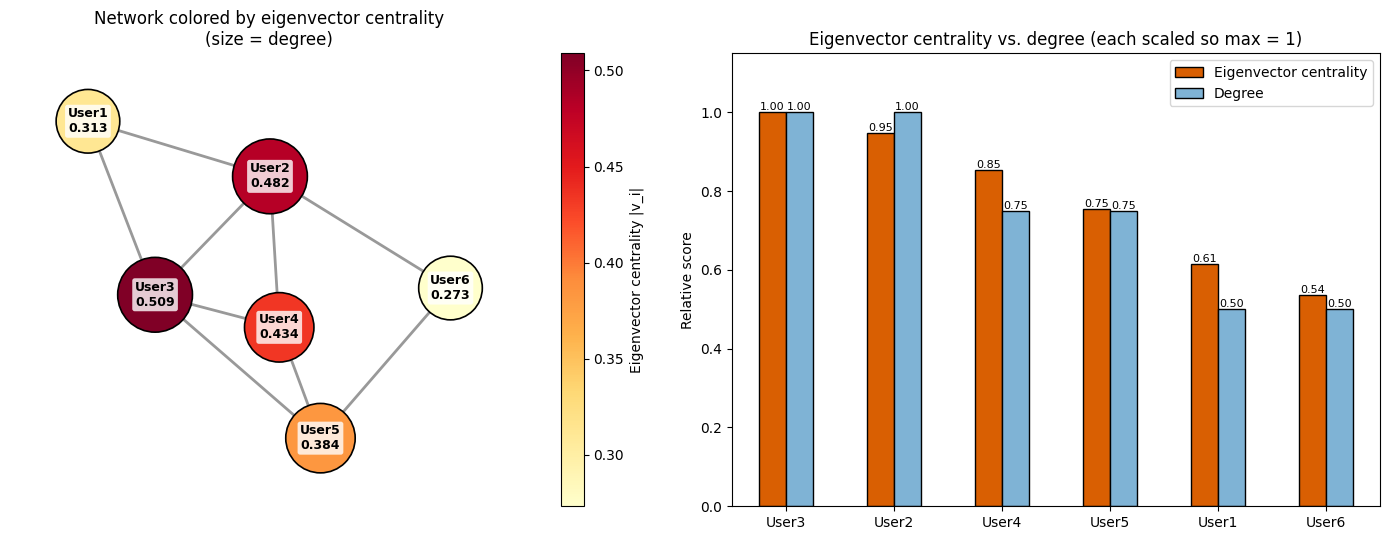

In [40]:
# visual comparison - degree vs eigenvector centrality
fig, axes = plt.subplots(1, 2, figsize=(14, 5.5))

scores = {u: np.abs(v)[i] for i, u in enumerate(users)}
nodes = nx.draw_networkx_nodes(G, pos, ax=axes[0],
                               node_size=[1300 + 400 * degree[u] for u in G.nodes()],
                               node_color=[scores[u] for u in G.nodes()],
                               cmap="YlOrRd", edgecolors="black", linewidths=1.2)
nx.draw_networkx_edges(G, pos, ax=axes[0], width=2, edge_color="#999999")
nx.draw_networkx_labels(G, pos, ax=axes[0],
                        labels={u: f"{u}\n{scores[u]:.3f}" for u in G.nodes()},
                        font_size=9, font_weight="bold",
                        bbox=dict(boxstyle="round,pad=0.2", fc="white", ec="none", alpha=0.8))
fig.colorbar(nodes, ax=axes[0], label="Eigenvector centrality |v_i|")
axes[0].set_title("Network colored by eigenvector centrality\n(size = degree)")
axes[0].axis("off")
axes[0].margins(0.15)

plot_df = ranking[["Relative score (top = 1)"]].copy()
plot_df["Degree (scaled, top = 1)"] = ranking["Degree"] / ranking["Degree"].max()
plot_df.columns = ["Eigenvector centrality", "Degree"]
plot_df.plot(kind="bar", ax=axes[1], color=["#d95f02", "#7fb3d5"], edgecolor="black")
axes[1].set_title("Eigenvector centrality vs. degree (each scaled so max = 1)")
axes[1].set_ylabel("Relative score")
axes[1].set_xlabel("")
axes[1].set_ylim(0, 1.15)
axes[1].tick_params(axis="x", rotation=0)
for container in axes[1].containers:
    axes[1].bar_label(container, fmt="%.2f", fontsize=8)

plt.tight_layout()
plt.show()

**Summary of Part B**

| Item | Result |
|---|---|
| Dominant eigenvalue | $\lambda \approx 3.1692$ |
| Verification $A\mathbf{v} \approx \lambda\mathbf{v}$ | Passed (also confirmed with `eigh` and power iteration) |
| Most influential user | **User3** (component ≈ 0.509) |
| Full ranking | User3 > User2 > User4 > User5 > User1 > User6 |

Just degree could not choose between user2 and user3. However, eigenvector centrality breaks that tie in favor of user3 because user3's connections lead to better connected users.

## Part C: Business Recommendation

**Priority** The eigen analysis points to user3 as the most influential user (relative score 1.00), followed pretty close by user2 (with 0.95). These two form the core of the network as they are directly linked to each other and together reach every other user in a single step. I would treat both of them as a tier 1 pair since the gap between them is small and partnering with both covers the entire network. User4 (0.85) and user5 (0.75) make a pretty reasonable tier 2 for reinforcing the message, while user1 (0.61) and ser6 (0.54) are peripheral and better reached indirectly through the core.

**Eigenvector centrality vs. counting connections** Degree treats every connection as having the same value, so user2 and user3 tie at four connections each. Eigenvector centrality scores a user by the importance of the people they are connected to, which is exactly what $A\mathbf{v} = \lambda\mathbf{v}$ encodes, meaning each user's score is proportional to the sum of their neighbors' scores. User3 comes out ahead because its neighbors are better connected, while one of user2's links goes to user6, a peripheral user.

**eigenvectors** Influence is circular, which means that you matter if you are connected to people who matter. The dominant eigenvector resolves that in one consistent set of scores, and because the matrix is nonnegative and connected, those scores are all positive and meaningful to rank. It captures how a message would spread over multiple steps, not just to immediate contacts.

**Note** This analysis only uses who is connected to whom. It ignores how strong or active each connection is, treats all links as mutual, and says nothing about whether a user's audience cares about the product.
